# Testing SNEC dev
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import SNEC_output_parser, plot_vel_radius_at_time_t, plot_mass_radius, plot_v_radius_time, get_times, plot_rho_pfile
import astropy.units as u
%load_ext autoreload
%autoreload 2

Hardcoded some constants


In [2]:
root = "/home/mrenzo/Documents/Research/codes/SNEC-1.01/Data/"

baseline = root+'new_baseline2/'  # test nothing is broken

bomb_minus10 = root+'bomb-10/'
bomb_minus1 = root+'bomb-1/'
bomb0 = root+'bomb0.0d0/'
bomb40 = root+'bomb1d40/'
bomb48 = root+'bomb1d48/'


# file names
baseline_vel = baseline+"vel.xg"
baseline_mass = baseline+"mass.xg"
baseline_rho = baseline+"rho.xg"

bomb_minus10_vel = bomb_minus10+"vel.xg"
bomb_minus10_mass = bomb_minus10+"mass.xg"
bomb_minus10_rho = bomb_minus10+"rho.xg"

bomb_minus1_vel = bomb_minus1+"vel.xg"
bomb_minus1_mass = bomb_minus1+"mass.xg"
bomb_minus1_rho = bomb_minus1+"rho.xg"

bomb0_vel = bomb0+"vel.xg"
bomb0_mass = bomb0+"mass.xg"
bomb0_rho = bomb0+"rho.xg"

bomb40_vel = bomb40+"vel.xg"
bomb40_mass = bomb40+"mass.xg"
bomb40_rho = bomb40+"rho.xg"


bomb48_vel = bomb48+"vel.xg"
bomb48_mass = bomb48+"mass.xg"
bomb48_rho = bomb48+"rho.xg"

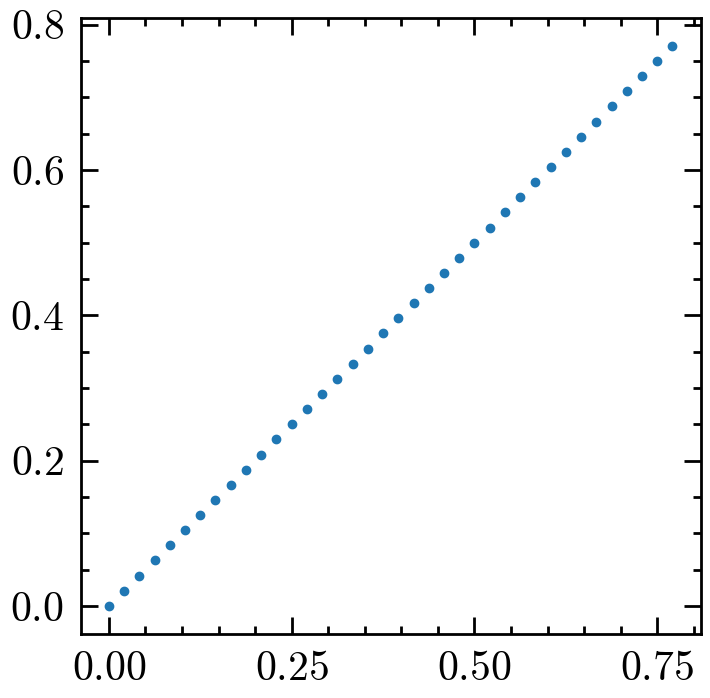

In [65]:
# checkpoint times
def plot_timestep_size(folder):
    delta_time = folder+"/delta_time.xg"
    data = SNEC_output_parser(delta_time)
    keys = np.array(list(data.keys()))
    times = keys * u.s
    try:
        units = times.unit
    except AttributeError:
        times *= u.s
    fig = plt.figure()
    gs = gridspec.GridSpec(150, 100)
    ax = fig.add_subplot(gs[:, :])
    ax.scatter(times.to(u.d), times.to(u.d))

plot_timestep_size(bomb_minus10)

Text(0.5, 0, '$m \\ [M_{\\odot}]$')

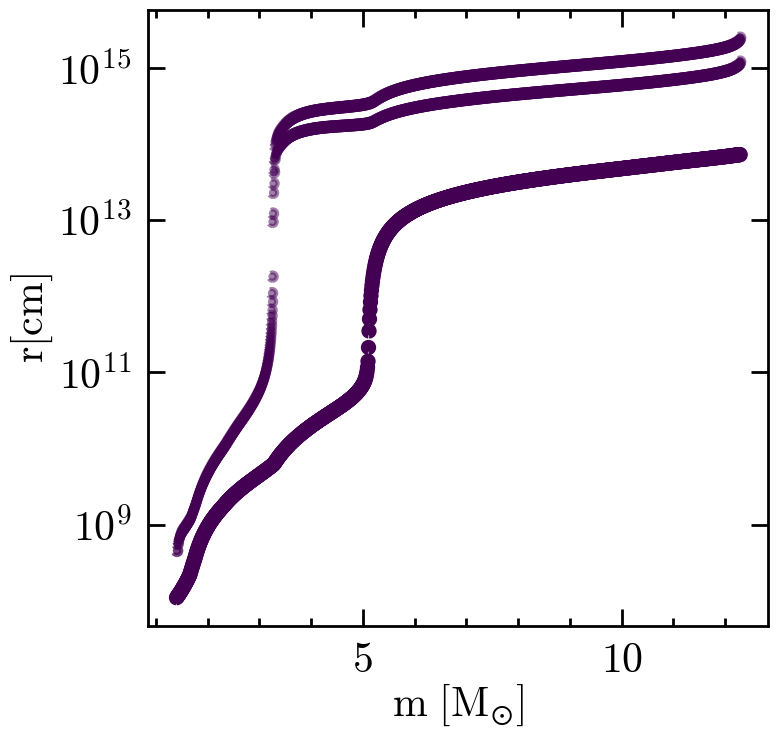

In [16]:
# mass vs time
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])


# get times 
vel_data = SNEC_output_parser(baseline_vel)
keys = np.array(list(vel_data.keys()))
vel_times = keys * u.s

for i, t in enumerate(vel_times[::2000]):
    zorder=1
    ls='--'
    lw=3
    alpha=0.5
    if i==0:
        # starting point
        c='r'
        zorder=0
        lw=5
        alpha=1
    plot_mass_radius(t, baseline_mass, ls=ls, ax=ax, lw=lw, alpha=alpha, zorder=zorder)


bomb_minus1_data = SNEC_output_parser(bomb_minus1_vel)
keys = np.array(list(vel_data.keys()))
bomb_minus1_times = keys * u.s

    
# for i, t in enumerate(bomb_minus1_times):
#     zorder=1
#     ls='-'
#     lw=3
#     alpha=0.5
#     if i==0:
#         # starting point
#         zorder=0
#         ls='-'
#         lw=5
#         alpha=1
#     plot_mass_radius(t, bomb_minus1_mass, ls=ls, ax=ax, lw=lw, alpha=alpha, zorder=zorder)
#     # plot_mass_radius(t, bomb48_mass, ls='--', c=colors[i], ax=ax, lw=4, alpha=0.5, zorder=0)
#     # plot_mass_radius(t, bomb0_mass, ls='-', c=colors[i], ax=ax, lw=3, alpha=0.5, zorder=0)
#     # plot_mass_radius(t, fallback1_mass, ls='-', c=colors[i], ax=ax, zorder=2)
    
ax.set_yscale('log')
# ax.set_yscale("symlog", linthresh=1e14, linscale=1.5)
# ax.set_ylabel(r"$\log_{10}(r/\mathrm{cm})$")
ax.set_ylabel(r"$r [\mathrm{cm}]$")
ax.set_xlabel(r"$m \ [M_{\odot}]$")

In [11]:
# define colors
mass_times = get_times(bomb_minus10_mass)
colors = plt.cm.viridis(np.linspace(0,1, len(mass_times)))

38


new_baseline2


bomb-10


bomb-1


bomb0.0d0


bomb1d40


bomb1d40


/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  func(*args, **kwargs)


/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


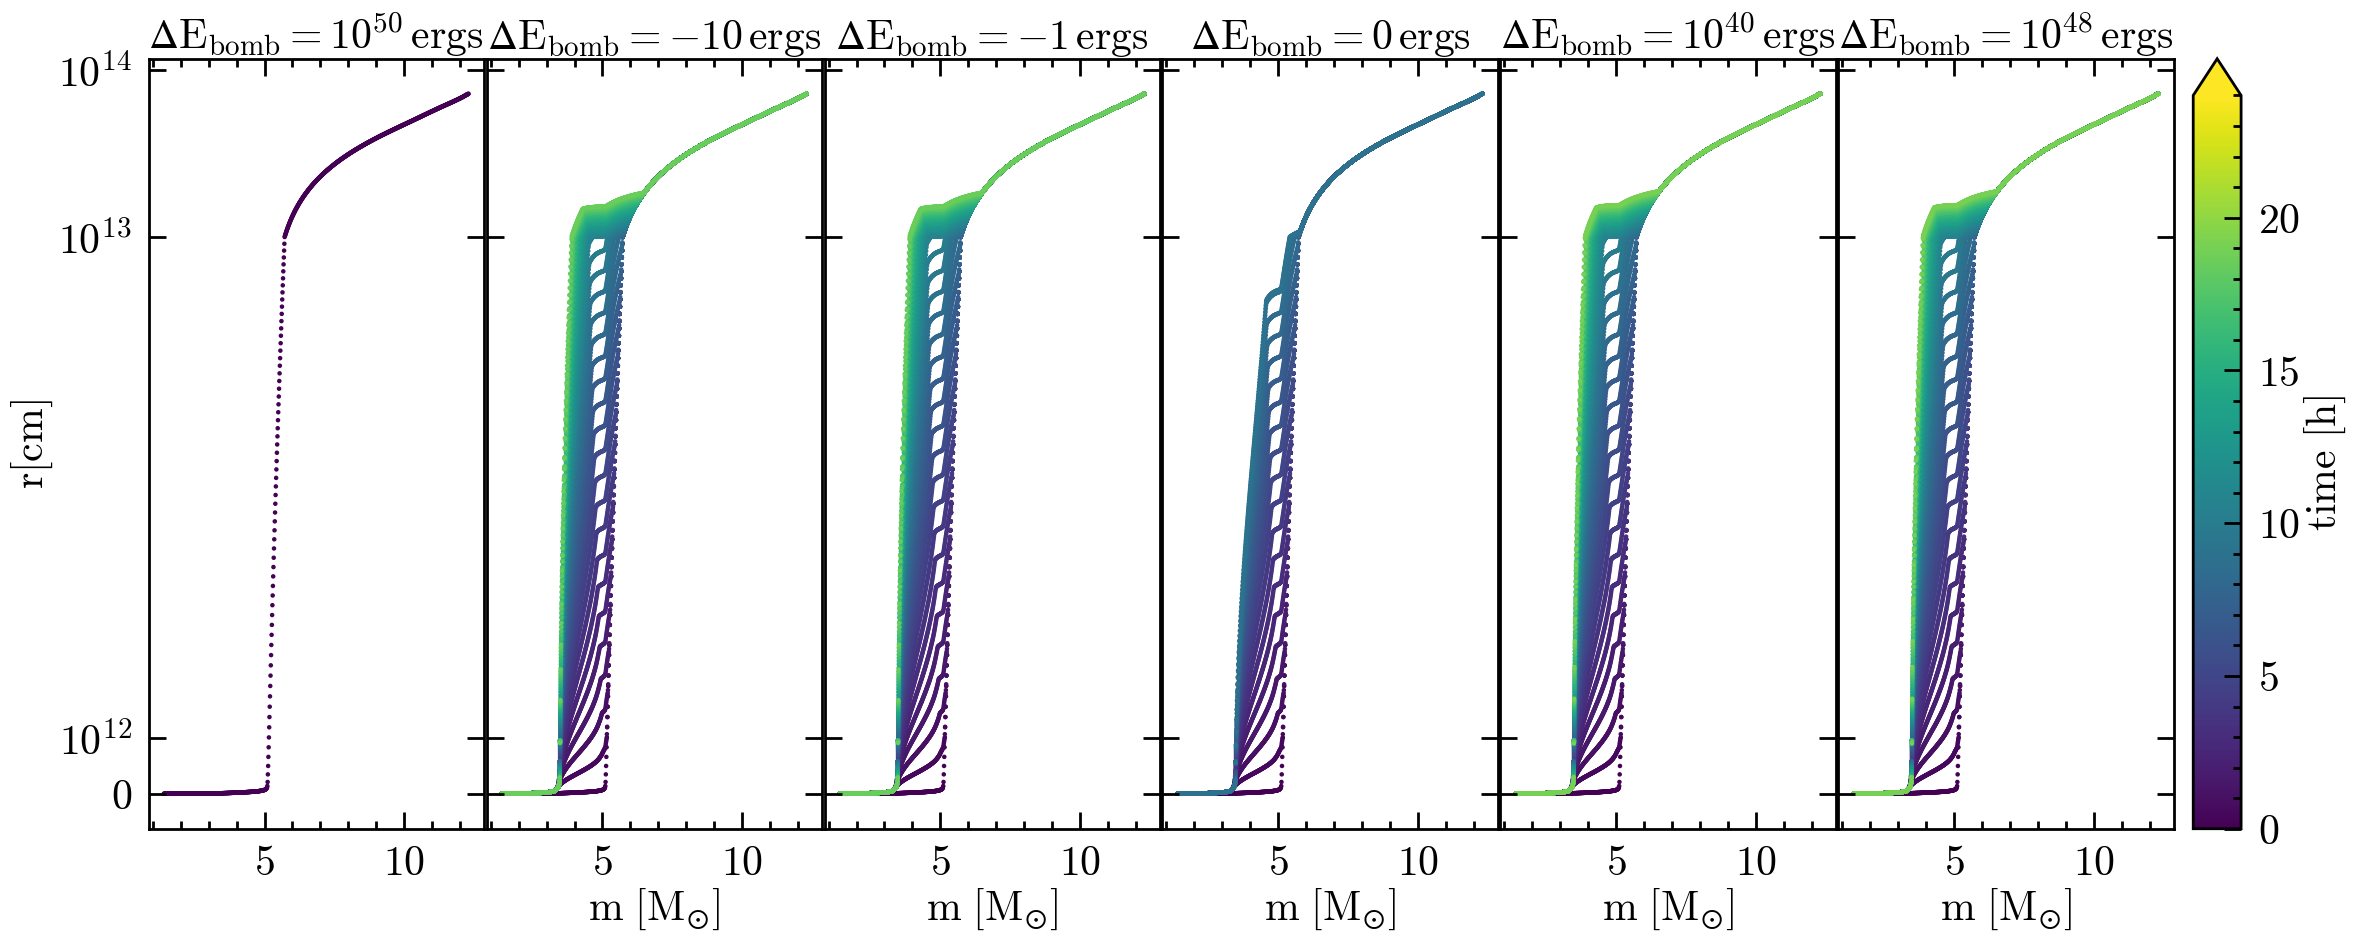

In [20]:
# mass vs. time multipanel
fig = plt.figure(figsize=(27,10))
gs = gridspec.GridSpec(120, 124)
ax1 = fig.add_subplot(gs[:,:20])
ax2 = fig.add_subplot(gs[:,20:40])
ax3 = fig.add_subplot(gs[:,40:60])
ax4 = fig.add_subplot(gs[:,60:80])
ax5 = fig.add_subplot(gs[:,80:100])
ax6 = fig.add_subplot(gs[:,100:120])
cax = fig.add_subplot(gs[:,121:])


def wrapper_mass_radius_plot(mass_file, ax, skip=1000, **kwargs):
    print(mass_file.split('/')[-2])
    times = get_times(mass_file)
    for i, t in enumerate(times[::skip]):
        if t.to(u.h) > 50*u.h: return 0, 0, None
        m, r, p = plot_mass_radius(t, mass_file, ax=ax, s=5, vmin=0, vmax=24, **kwargs)
    return m, r, p
       
m, r, p = wrapper_mass_radius_plot(baseline_mass, ax1, skip=500)
ax1.set_title(r"$\Delta E_{\rm bomb}=10^{50}\,\mathrm{ergs}$", size=30)

m, r, p = wrapper_mass_radius_plot(bomb_minus10_mass, ax2, skip=1)
ax2.set_title(r"$\Delta E_{\rm bomb}=-10\,\mathrm{ergs}$", size=30)

m, r, p = wrapper_mass_radius_plot(bomb_minus1_mass, ax3, skip=1)
ax3.set_title(r"$\Delta E_{\rm bomb}=-1\,\mathrm{ergs}$", size=30)

m, r, p = wrapper_mass_radius_plot(bomb0_mass, ax4, skip=1)
ax4.set_title(r"$\Delta E_{\rm bomb}=0\,\mathrm{ergs}$", size=30)

m, r, p = wrapper_mass_radius_plot(bomb40_mass, ax5, skip=1)
ax5.set_title(r"$\Delta E_{\rm bomb}=10^{40}\,\mathrm{ergs}$", size=30)

m, r, p = wrapper_mass_radius_plot(bomb40_mass, ax6, skip=1)
ax6.set_title(r"$\Delta E_{\rm bomb}=10^{48}\,\mathrm{ergs}$", size=30)

plt.colorbar(p, cax=cax, extend="max")
cax.set_ylabel(r"$\mathrm{time} \ [\mathrm{h}]$")

# beautification
ax1.set_ylabel(r"$r [\mathrm{cm}]$")
ax1.set_yscale("symlog", linthresh=1e13, linscale=3)
ax1.set_xlabel(r"$m \ [M_{\odot}]$")

for ax in [ax2, ax3, ax4, ax5, ax6]:
    ax.set_xlim(ax1.get_xlim())
    ax.set_ylim(ax1.get_ylim())
    ax.set_xlabel(r"$m \ [M_{\odot}]$")
    ax.set_yscale("symlog", linthresh=1e13, linscale=3)
    ax.set_yticklabels([])
    

/home/mrenzo/Documents/Research/codes/SNEC-1.01/scripts/plot_aux.py:370: RuntimeWarning: invalid value encountered in log10
  ax.axvline(np.log10(radius[i_min_m].value), 0, 1, zorder=0, ls='--', lw=1, c='k')
/home/mrenzo/Documents/Research/codes/SNEC-1.01/scripts/plot_aux.py:373: RuntimeWarning: invalid value encountered in log10
  ax.plot(np.log10(radius.value), vel, **kwargs)


Text(0, 0.5, '$v \\ [\\mathrm{km\\ s^{-1}}]$')

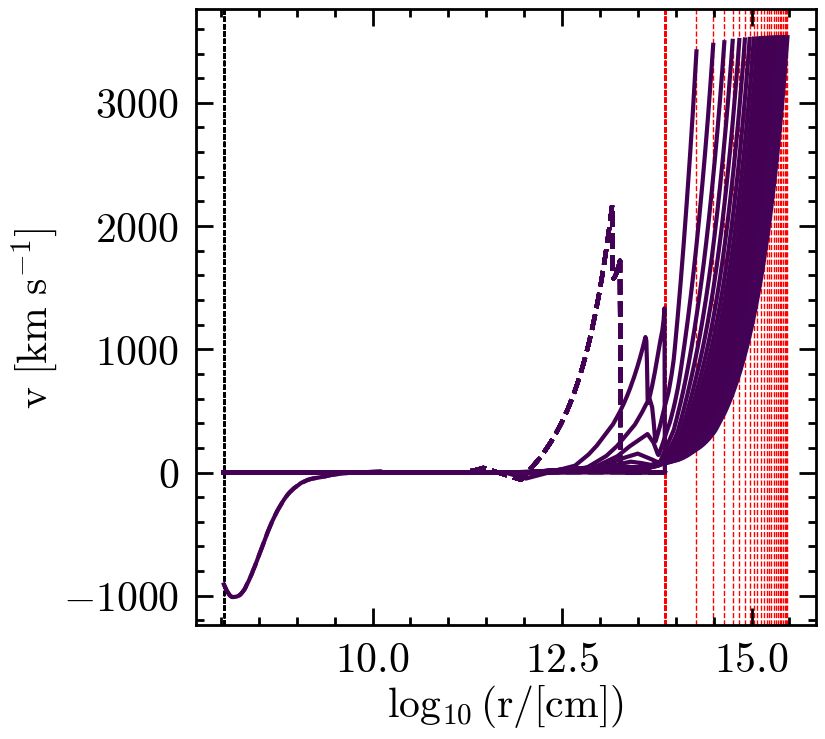

In [7]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for i, t in enumerate(vel_times[::200]):
    # if i%2 ==0: continue
    # alpha = max(min(1.0-(0.8 - 0.01*i), 1.0), 0.0)
    plot_v_radius_time(t, baseline_vel, baseline_mass, ax=ax, ls='-', lw=3, # label=f"{t.to(u.h):.1f}",
                       c=colors[i], # alpha=alpha
                       )
    plot_v_radius_time(t, bomb_minus1_vel, bomb_minus1_mass, ax=ax, label=f"{t.to(u.h):.1f}", zorder=1, ls='--',
                       # alpha=alpha,
                       c=colors[i]
                       )
    # plot_v_radius_time(t, bomb0_vel, bomb0_mass, ax=ax, label=f"{t.to(u.h):.1f}", zorder=1,
    #                    ls='--',# alpha=alpha,
    #                    c=colors[-1]
    #                    )
    

ax.set_xlabel(r'$\log_{10}(r/\mathrm{[cm]})$')
ax.set_ylabel(r'$v \ [\mathrm{km\ s^{-1}}]$')
# ax.legend(ncol=3, fontsize=20)
# ax.set_ylim(-10, 10)

In [21]:
# Mass vs time
mass_data = SNEC_output_parser(baseline_mass)
keys = np.array(list(mass_data.keys()))
mass_times = keys * u.s

for i, t in enumerate(mass_times[::100]):
    mass = mass_data[keys[i]][:, 1] * u.g
    print(t.to(u.d), min(mass).to(u.Msun), max(mass).to(u.Msun),mass[1].to(u.Msun), mass[-1].to(u.Msun))

25.104167461859646 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.125001197159154 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.145834383103146 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.1666677029029 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.187501156465725 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.208334063766884 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.22916780294399 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.250000992361514 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292

25.854167799877743 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.87500090791724 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.895834144963725 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.916667512273012 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.937501017561218 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.958334655855964 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
25.979167739528652 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
26.000000960783876 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.2

26.60416738730293 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
26.625001121954753 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
26.645834303159816 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
26.666667617218156 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
26.68750105123655 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
26.708334620684532 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
26.729167634996813 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
26.750000782785197 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.29

27.35416762475122 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
27.375001213095814 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
27.39583423055117 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
27.416667376111892 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
27.437501339883482 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
27.458334044222568 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
27.479167561156558 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
27.50000120945666 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292

28.104167427099945 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
28.12500069858484 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
28.14583409093507 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
28.166667615926123 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
28.18750126687054 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
28.208334345810083 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
28.229167549409546 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
28.25000087714521 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.2921

...

98.000001094369 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.02083441893772 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.04166780268784 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.06250124537034 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.08333404809258 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.10416760874342 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.12500122822355 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.14583420643041 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.2921357111

98.72916748864752 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.75000077679302 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.77083412375178 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.79166752979941 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.81250099289049 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.83333451619573 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.85416739814401 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
98.87500103776517 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.29213571

99.47916796561996 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
99.50000127149045 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
99.52083463396465 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
99.54166805632906 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
99.5625008351835 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
99.58333437433197 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
99.60416797140309 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
99.62500092725944 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711

0.0 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
2.0833340291545133 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
4.166667935045691 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
6.250000903005747 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
8.33333409351244 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
10.416667567726131 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
12.500000902747566 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
14.583334217048863 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 sol

72.91666758275056 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
75.00000070121524 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
77.0833347062879 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
79.16666775688725 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
81.25000103708315 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
83.3333342827646 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
85.4166679655776 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.292135711144635 solMass
87.50000127762667 d 1.400359171935954 solMass 12.292135711144635 solMass 1.4098716405063094 solMass 12.29213571114

/tmp/ipykernel_1255757/1378338945.py:14: RuntimeWarning: divide by zero encountered in log10
  ax.plot(mass.to(u.Msun), np.log10(rho.value), **kwargs)


Text(0.5, 0, '$m \\ [M_{\\odot}]$')

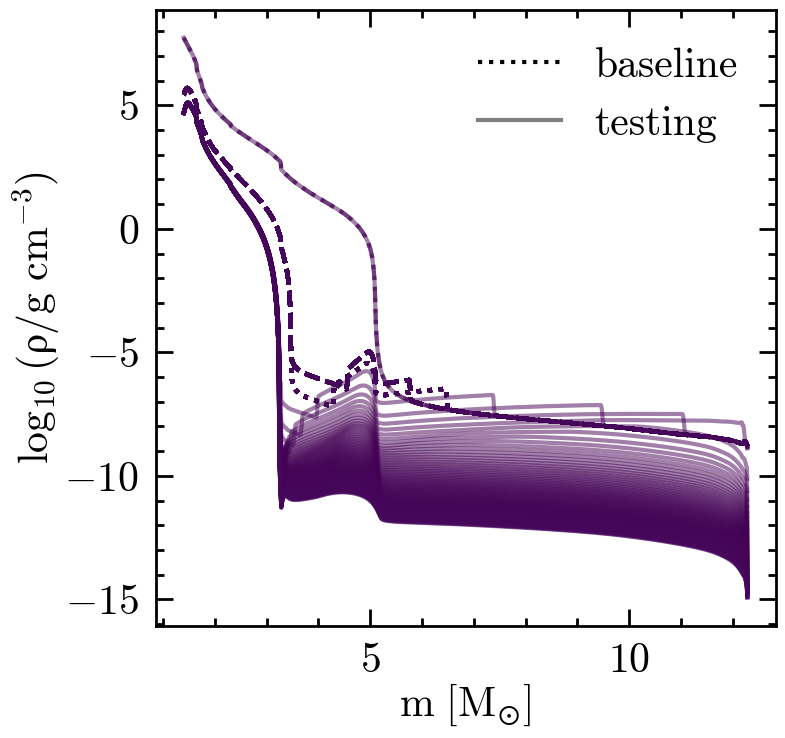

In [8]:
# density profiles?
def plot_rho_pfile(t, rho_out, ax=None, **kwargs):
    data = SNEC_output_parser(rho_out)
    keys = np.array(list(data.keys()))
    times = keys * u.s
    try:
        units = times.unit
    except AttributeError:
        times *= u.s
    index_time_of_interest = np.argmin(np.absolute(times-t))
    key_of_interest = keys[index_time_of_interest]
    rho = data[key_of_interest][:, 1] * u.g/u.cm**3
    mass = data[key_of_interest][:, 0] * u.g
    ax.plot(mass.to(u.Msun), np.log10(rho.value), **kwargs)



fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])


for i, t in enumerate(vel_times[::50]):
    # print(i)
    plot_rho_pfile(t, baseline_rho, ax=ax, # label=f'{t}',
                   c=colors[i], lw=3, alpha=0.5)
    plot_rho_pfile(t, bomb0_rho, ax=ax, ls='--', alpha=0.5, c=colors[i])
    plot_rho_pfile(t, bomb_minus1_rho, ax=ax, ls=':', alpha=0.5, c=colors[i])


ax.plot(np.nan, np.nan, ls=":", c='k', label="baseline")
ax.plot(np.nan, np.nan, lw=3, c='k', alpha=0.5, label="testing") # r"$E_{\rm final}=0$")
ax.legend()
ax.set_ylabel(r"$\log_{10}(\rho/\mathrm{g\ cm^{-3}})$")
ax.set_xlabel(r"$m \ [M_{\odot}]$")

/tmp/ipykernel_1211201/3394954984.py:16: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.log10(radius.to(u.cm).value), np.log10(rho.value), **kwargs)


Text(0.5, 0, '$\\log_{10}(r/\\mathrm{cm})$')

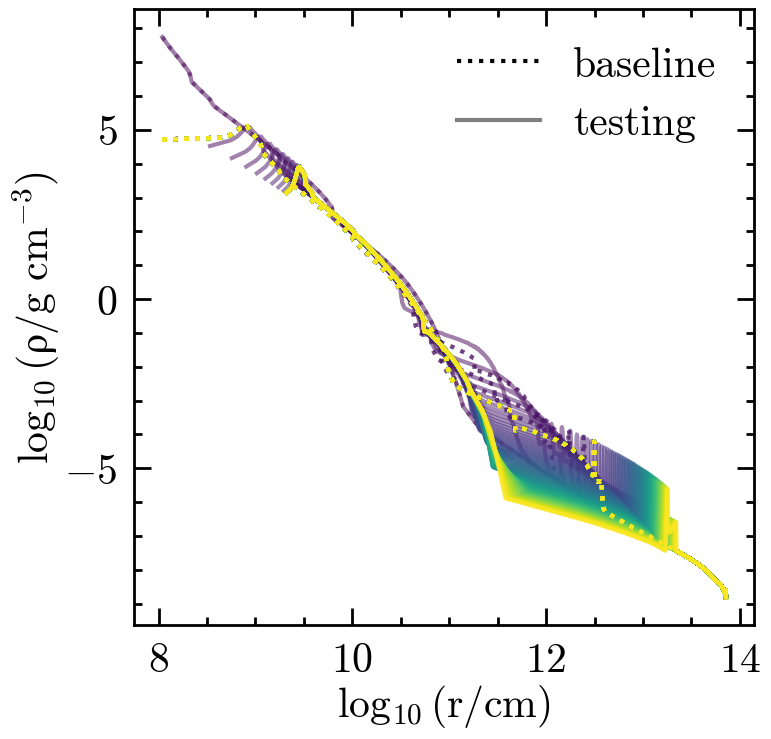

In [34]:
# Density vs. Radius
def plot_rho_r_pfile(t, rho_out, mass_out, ax=None, **kwargs):
    data = SNEC_output_parser(rho_out)
    keys = np.array(list(data.keys()))
    times = keys * u.s
    try:
        units = times.unit
    except AttributeError:
        times *= u.s
    index_time_of_interest = np.argmin(np.absolute(times-t))
    key_of_interest = keys[index_time_of_interest]
    rho = data[key_of_interest][:, 1] * u.g/u.cm**3
    mass = data[key_of_interest][:, 0] * u.g
    mass_data = SNEC_output_parser(mass_out)
    radius = mass_data[key_of_interest][:, 0] * u.cm
    ax.plot(np.log10(radius.to(u.cm).value), np.log10(rho.value), **kwargs)



fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for i, t in enumerate(vel_times):
    # print(i)
    plot_rho_r_pfile(t, fallback1_rho, fallback1_mass, ax=ax, # label=f'{t}',
                     c=colors[i], lw=3, alpha=0.5)
    plot_rho_r_pfile(t, baseline_rho, baseline_mass,  ax=ax, ls=':', alpha=0.5, c=colors[i])


ax.plot(np.nan, np.nan, ls=":", c='k', label="baseline")
ax.plot(np.nan, np.nan, lw=3, c='k', alpha=0.5, label="testing") # r"$E_{\rm final}=0$")
ax.legend()
ax.set_ylabel(r"$\log_{10}(\rho/\mathrm{g\ cm^{-3}})$")
ax.set_xlabel(r"$\log_{10}(r/\mathrm{cm})$")


/tmp/ipykernel_1297272/1995857692.py:12: RuntimeWarning: divide by zero encountered in log10
  ax.plot(t.to(u.d), np.log10(L.value), **kwargs)


Text(0, 0.5, '$\\log_{10}(L/\\mathrm{erg\\ s^{-1}})$')

/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  func(*args, **kwargs)
/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


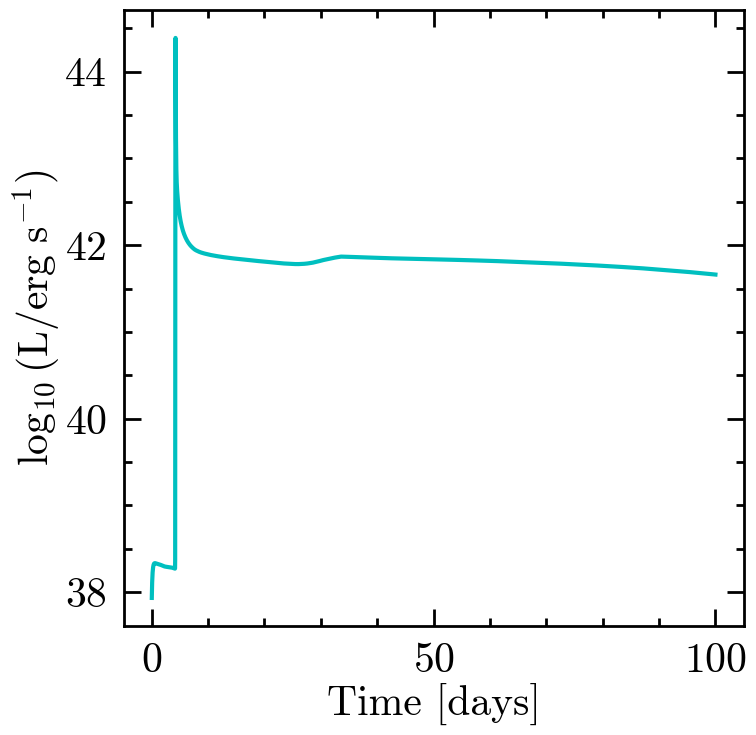

In [3]:
# light curve?
def plot_LC(folder, ax=None, **kwargs):
    obs_lum = folder+'lum_observed.dat'
    src = np.genfromtxt(obs_lum)
    t = src[:, 0] * u.s
    L = src[:,1] * u.erg/u.s
    if not ax:
        fig = plt.figure()
        gs = gridspec.GridSpec(150, 100)
        ax = fig.add_subplot(gs[:, :])
    #ax.scatter(t.to(u.d), np.log10(L.value), **kwargs)
    ax.plot(t.to(u.d), np.log10(L.value), **kwargs)


fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

plot_LC(baseline, ax=ax, c='c', lw=3)
# plot_LC(bomb_minus1, ax=ax, c='b', lw=3)
# plot_LC(bomb0, ax=ax, c='r', lw=5)
# plot_LC(bomb48, ax=ax, c='g', lw=7)
# plot_LC(fallback1, ax=ax, c='y', lw=9)


ax.set_xlabel(r"Time [days]")
ax.set_ylabel(r"$\log_{10}(L/\mathrm{erg\ s^{-1}})$")